In [123]:
img_path = "../data/raw"

In [124]:
from pathlib import Path

folder_path = Path(img_path)

image_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}

image_path_objects = [
    file for file in folder_path.iterdir() 
    if file.is_file() and file.suffix.lower() in image_extensions
]

image_list = [str(path) for path in image_path_objects]

print(f"Đã tìm thấy {len(image_list)} ảnh.")
print(image_list)

Đã tìm thấy 8 ảnh.
['..\\data\\raw\\img1.jpg', '..\\data\\raw\\img2.jpg', '..\\data\\raw\\img3.jpg', '..\\data\\raw\\img4.jpg', '..\\data\\raw\\img5.jpg', '..\\data\\raw\\img6.jpg', '..\\data\\raw\\img7.jpg', '..\\data\\raw\\img8.jpg']


In [125]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_image(file_path):
    img = cv2.imread(file_path)
    if img is None:
        raise ValueError(f"Cannot find path.")
    return img

In [126]:
def resize_and_crop(img, target_width=800, target_height=600, crop_margin=50):
    """
    Resize x Crop
    """
    img_resized = cv2.resize(img, (target_width, target_height))
    
    img_cropped = img_resized[crop_margin : target_height - crop_margin, 
                              crop_margin : target_width - crop_margin]
    return img_cropped

In [127]:
def convert_to_grayscale(img):
    """
    Convert to grayscale
    """
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [128]:
def balance_brightness(img_gray, clip_limit=2.0, grid_size=(8, 8)):
    """
    (Contrast Limited Adaptive Histogram Equalization).
    """
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    return clahe.apply(img_gray)

In [129]:
def reduce_noise_gaussian(img_gray, kernel_size=(5, 5), sigma_x=0):
    return cv2.GaussianBlur(img_gray, kernel_size, sigmaX=sigma_x)

In [130]:
def preprocess (
            img_path, 
            target_width=800, 
            target_height=600, 
            crop_margin=50, 
            clip_limit=2.0, 
            grid_size=(8, 8), 
            kernel_size=(5, 5), 
            sigma_x=0):
    img = read_image(img_path)
    img = resize_and_crop(img, target_width=target_width, target_height=target_height, crop_margin=crop_margin)
    img = convert_to_grayscale(img)
    img = balance_brightness(img, clip_limit=clip_limit, grid_size=grid_size)
    return reduce_noise_gaussian(img, kernel_size=kernel_size, sigma_x=sigma_x)

In [131]:
def plot_comparison(img1, img2, title1, title2, cmap1=None, cmap2=None):
    """Hàm phụ trợ để hiển thị nhanh 2 ảnh cạnh nhau"""
    # Phải có (1, 2) để tạo ra 1 hàng, 2 cột
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Hiển thị ảnh 1 ở cột bên trái (axes[0])
    axes[0].imshow(img1, cmap=cmap1)
    axes[0].set_title(title1, fontsize=14)
    axes[0].axis('off')
    
    # Hiển thị ảnh 2 ở cột bên phải (axes[1])
    axes[1].imshow(img2, cmap=cmap2)
    axes[1].set_title(title2, fontsize=14)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

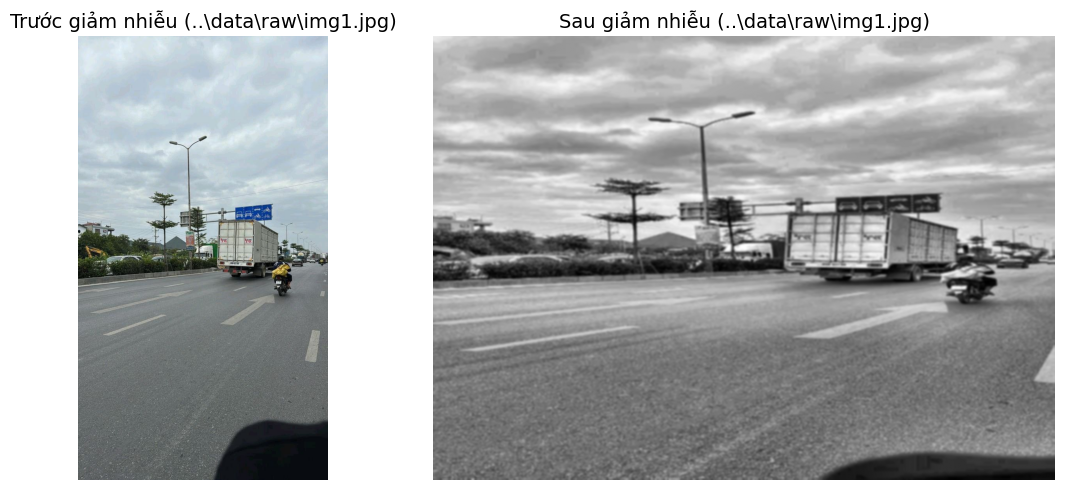

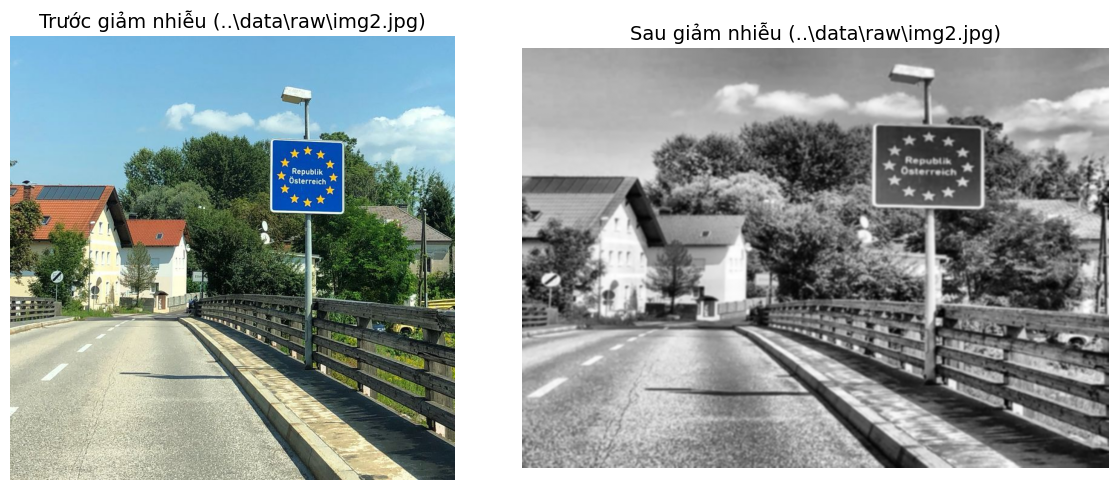

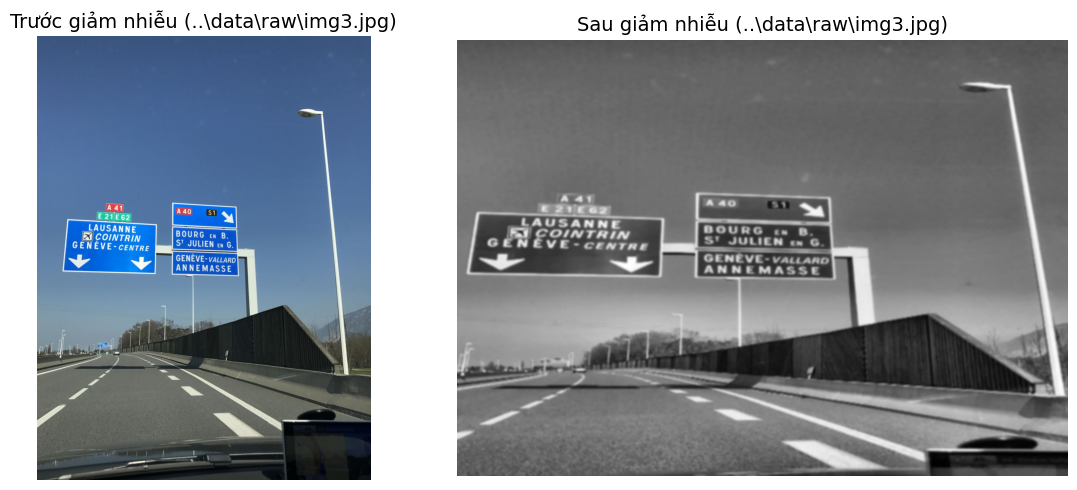

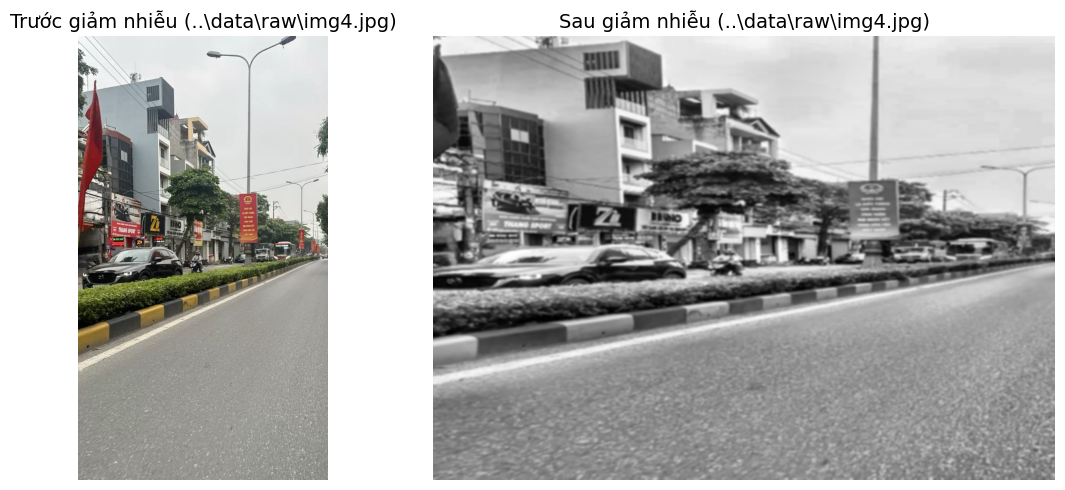

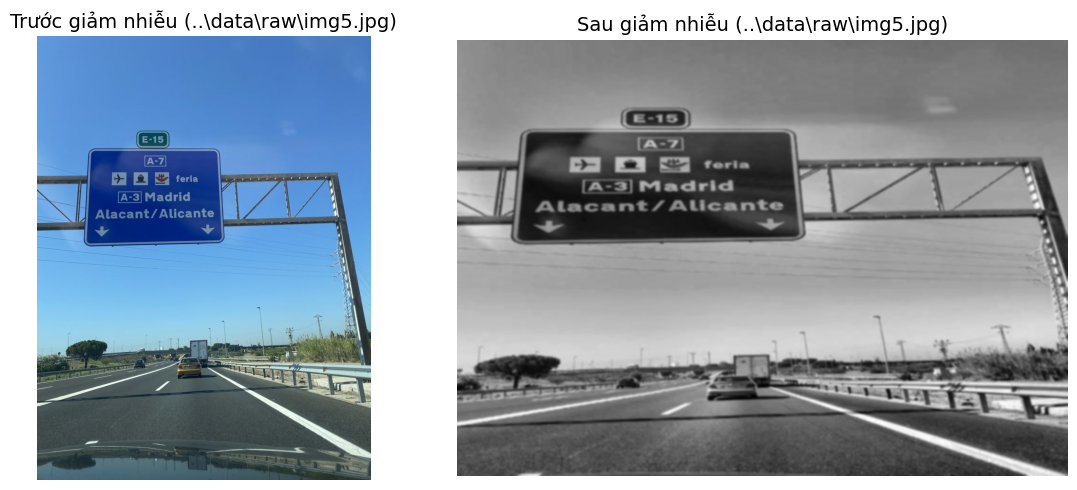

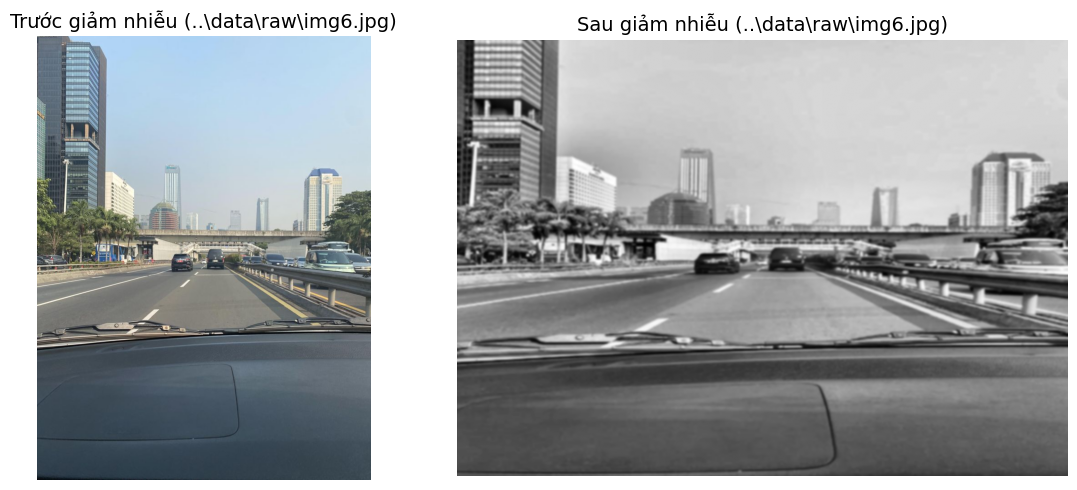

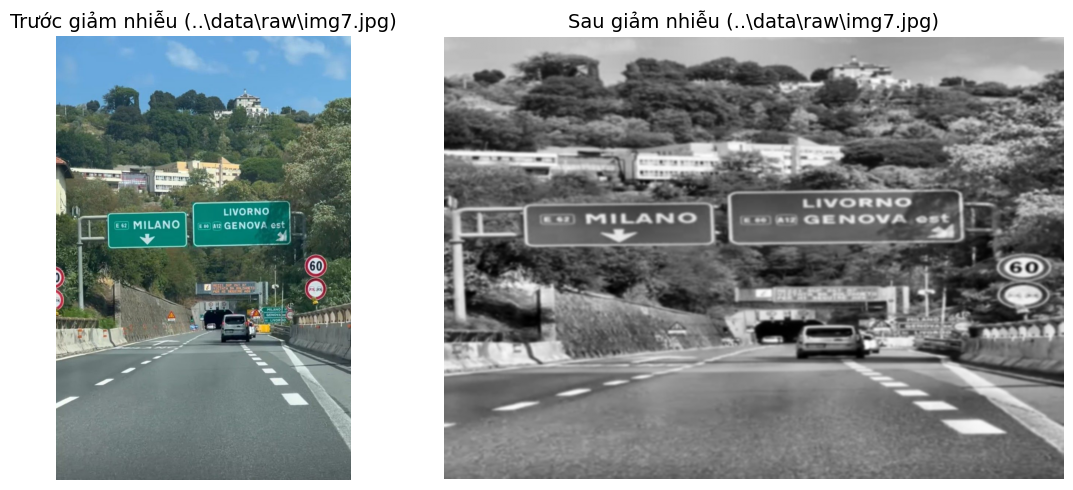

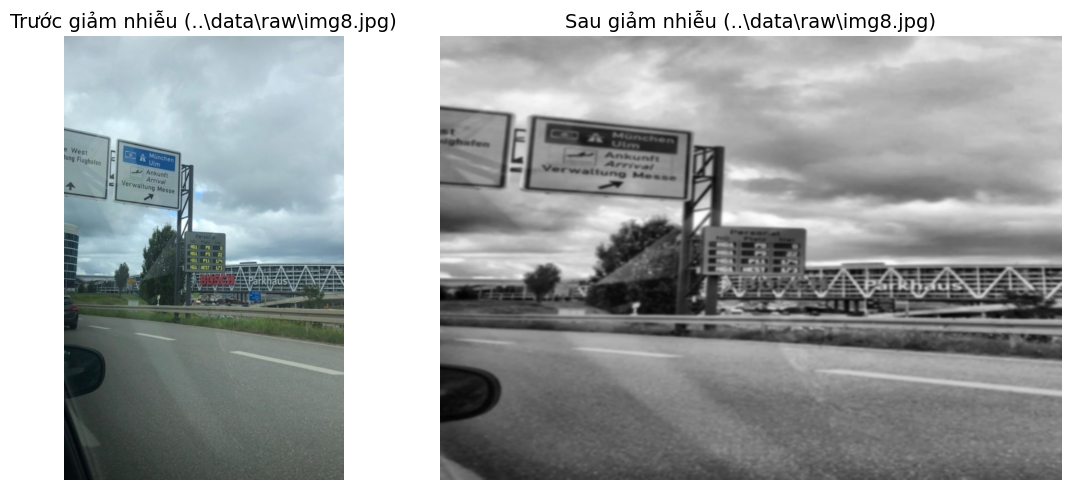

In [132]:

for img_path in image_list:
    # 1. Đọc ảnh (nếu lỗi thì bỏ qua vòng lặp hiện tại, đi tới ảnh tiếp theo)
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f"Lỗi: Không đọc được {img_path}")
        continue 

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    img_denoised = preprocess(img_path)
    # 3. Hiển thị
    plot_comparison(
        img_rgb, img_denoised,
        f'Trước giảm nhiễu ({img_path})', f'Sau giảm nhiễu ({img_path})',
         cmap2='gray'
    )

In [133]:
import os

save_path = '../data/processed/'
cropped_path = '../data/cropped/'


for image_path in image_list:
    # image_path lúc này là một chuỗi (string)
    image = preprocess(image_path)

    crop_image = read_image(image_path)
    crop_image = resize_and_crop(crop_image)
    
    # Dùng os.path.basename để lấy tên file từ chuỗi
    ten_file = os.path.basename(image_path)
    
    # Ghép đường dẫn với tên file
    final_destination = os.path.join(save_path, ten_file)
    
    # Lưu bằng OpenCV
    cv2.imwrite(final_destination, image)
    cv2.imwrite(os.path.join(cropped_path, ten_file), crop_image)

print ("finish!")

finish!
